# Scientific Validity of ASI for Binary Mean Estimation

This notebook provides empirical evidence that GLIDE's **Active Statistical Inference (ASI)** implementation is statistically valid.

**Setup:** We estimate the mean of a binary outcome (e.g., the pass rate of an LLM-as-a-judge evaluation). We have:
- A pool of `N_TOTAL` records, each with a proxy label (`y_proxy`) and an oracle proxy error (`rms_error`) that quantifies how unreliable the proxy is for each individual record
- A labeling budget of `N_LABELED` items: we can reveal the true label (`y_true`) for only a fraction of the pool

ASI selects which records to label using **oracle sampling** ($\pi_i \propto \text{rms\_error}_i$): records where the proxy is least reliable are labeled with higher probability. It then corrects for this non-uniform selection via **Inverse Probability Weighting (IPW)**, yielding confidence intervals that are:
1. **Valid** : they cover the true mean at the specified rate regardless of the sampling rule
2. **Shorter** : oracle sampling concentrates the labeling budget on uncertain items, producing shorter intervals than uniform sampling, especially when the proxy is informative

We test these two claims empirically across a range of proxy/true correlation levels.

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from glide.core.dataset import Dataset
from glide.core.simulated_datasets import generate_binary_dataset_with_oracle_sampling
from glide.estimators import ASIMeanEstimator, ClassicalMeanEstimator

## Experiment Parameters

We fix all parameters up front so every section of this notebook uses a consistent setup. We define :

- `CONFIDENCE_LEVEL` : the confidence level at which we will compute confidence intervals.

- `N_TOTAL` : the total number of records in the pool. Every record carries a proxy prediction and an oracle proxy error (`rms_error`).

- `N_LABELED` : the labeling budget. ASI uses **oracle sampling** (Bernoulli), so `N_LABELED` is the **expected** number of labeled records. The `True only` baseline uses exactly `N_LABELED` records drawn uniformly.

- `TRUE_MEAN` : the true mean value of human labels.

- `PROXY_MEAN` : the (biased) proxy mean value.

- `N_SEEDS` : the number of simulations we will run in our Monte Carlo experiments.

> **Note on correlation bounds:** Depending on the values of `TRUE_MEAN` and `PROXY_MEAN`, extreme correlation values (close to -1 or 1) may not be achievable. Correlation sweeps are kept within these limits.

Finally, we define the estimation methods that we will compare which are the following :

- `True only` : uses `N_LABELED` uniformly sampled true labels with a classical CLT confidence interval — the gold standard for validity.

- `Proxy only` : uses proxy labels only, without correction.

- `ASI` : Active Statistical Inference — oracle-sampled true labels + IPW-corrected proxy rectification.

In [15]:
CONFIDENCE_LEVEL = 0.9  # fixed throughout, 90% Confidence Interval
N_TOTAL = 1000   # total pool size (all records have oracle rms_error)
N_LABELED = 200  # labeling budget (expected for ASI with Bernoulli sampling, exact for True only)
TRUE_MEAN = 0.55
PROXY_MEAN = 0.5
N_SEEDS = 1000

METHODS = ["True only", "Proxy only", "ASI"]

correlations = np.arange(0.1, 0.95, 0.1)
correlations_lmh = [0.2, 0.5, 0.8]  # low, medium and high values
corr_labels = ["Low", "Medium", "High"]

## Data Generation

We use `generate_binary_dataset_with_oracle_sampling` to simulate a realistic evaluation scenario.
It generates `N_TOTAL` records, each containing:
- `y_true` : ground-truth binary label (latent — revealed only for labeled records)
- `y_proxy` : proxy binary prediction (always available)
- `rms_error` : oracle proxy error $\sqrt{\mathbb{E}[(y_{\text{proxy}} - y_{\text{true}})^2 \mid x_i]}$ — quantifies per-record proxy reliability

Records with high `rms_error` are those where the proxy is least reliable. ASI assigns higher labeling probability to these records:

$$\pi_i = \frac{N_{\text{labeled}} \cdot \text{rms\_error}_i}{\sum_j \text{rms\_error}_j}, \quad \pi_i \in (0, 1]$$

This concentrates the labeling budget on items where true labels add the most information.

The `build_dataset` helper below constructs the ASI dataset (oracle-sampled labels with $\pi_i$ attached) from the oracle pool. A uniform sample of `N_LABELED` records is also drawn to serve as the `True only` baseline.

In [16]:
def build_dataset(full_dataset, seed):
    # Build ASI (oracle sampling) and True-only (uniform sampling) datasets from the same oracle pool.
    # ASI: each record labeled with prob pi_i proportional to rms_error_i (expected N_LABELED labeled).
    # True only: exactly N_LABELED records chosen uniformly at random.
    data = full_dataset.to_numpy(fields=["y_true", "y_proxy", "rms_error"])
    y_true_all = data[:, 0].astype(int)
    y_proxy_all = data[:, 1].astype(int)
    rms_error = data[:, 2]
    N = len(full_dataset)

    # Separate RNG for labeling (seeds 100_000+ don't overlap with data gen seeds 0–N_SEEDS)
    rng = np.random.default_rng(seed + 100_000)

    # --- ASI: oracle sampling probabilities ---
    pi = N_LABELED * rms_error / rms_error.sum()
    excess_pi_mask = pi > 1
    excess_amount = pi[excess_pi_mask].sum() - excess_pi_mask.sum()
    pi[~excess_pi_mask] += excess_amount / (~excess_pi_mask).sum()
    pi = np.minimum(pi, 1.0)
    labeled_mask_asi = rng.random(N) < pi

    asi_records = []
    for i in range(N):
        record = {"y_proxy": int(y_proxy_all[i]), "pi": float(pi[i])}
        if labeled_mask_asi[i]:
            record["y_true"] = int(y_true_all[i])
        asi_records.append(record)

    # --- True only: uniform random sampling (exactly N_LABELED records) ---
    labeled_idx = set(rng.choice(N, size=N_LABELED, replace=False))
    true_only_records = []
    for i in range(N):
        record = {"y_proxy": int(y_proxy_all[i])}
        if i in labeled_idx:
            record["y_true"] = int(y_true_all[i])
        true_only_records.append(record)

    return Dataset(asi_records), Dataset(true_only_records)

Total records : 1000
Labeling budget : 200
ASI labeled (realized, Bernoulli) : 197
True only labeled (fixed, uniform) : 200

Oracle pi_i  — min: 0.1084, max: 0.2683, mean: 0.2000
Uniform  pi  — 0.2000 (constant for all records)


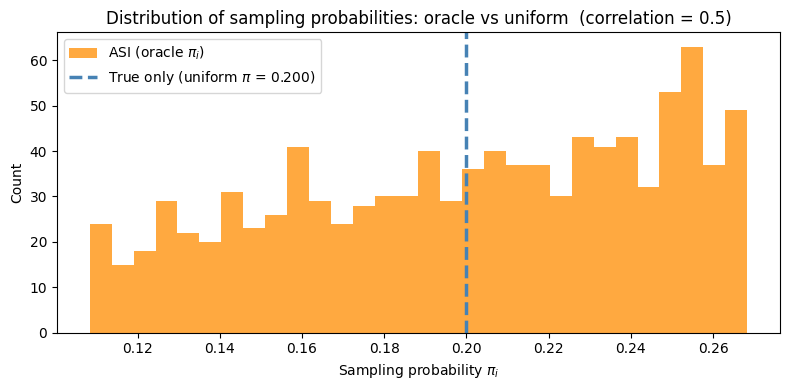

In [17]:
# Single example dataset for illustration (correlation = 0.5)
full_dataset = generate_binary_dataset_with_oracle_sampling(
    N=N_TOTAL,
    true_mean=TRUE_MEAN,
    proxy_mean=PROXY_MEAN,
    correlation=0.5,
    random_seed=42,
)
asi_dataset, true_only_dataset = build_dataset(full_dataset, seed=42)

pi_example = N_LABELED * full_dataset["rms_error"] / full_dataset["rms_error"].sum()
pi_example = np.minimum(pi_example, 1.0)
pi_uniform = N_LABELED / N_TOTAL

n_labeled_asi = int(np.sum(~np.isnan(asi_dataset["y_true"])))
print(f"Total records : {N_TOTAL}")
print(f"Labeling budget : {N_LABELED}")
print(f"ASI labeled (realized, Bernoulli) : {n_labeled_asi}")
print(f"True only labeled (fixed, uniform) : {N_LABELED}")
print(f"\nOracle pi_i  — min: {pi_example.min():.4f}, max: {pi_example.max():.4f}, mean: {pi_example.mean():.4f}")
print(f"Uniform  pi  — {pi_uniform:.4f} (constant for all records)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pi_example, bins=30, color="darkorange", alpha=0.75, label="ASI (oracle $\\pi_i$)")
ax.axvline(pi_uniform, color="steelblue", lw=2.5, linestyle="--", label=f"True only (uniform $\\pi$ = {pi_uniform:.3f})")
ax.set_xlabel("Sampling probability $\\pi_i$")
ax.set_ylabel("Count")
ax.set_title("Distribution of sampling probabilities: oracle vs uniform  (correlation = 0.5)")
ax.legend()
plt.tight_layout()
plt.show()

The histogram shows that oracle $\pi_i$ values are spread around the uniform value. Records where the proxy is unreliable (high `rms_error`) receive a higher sampling probability, while records where the proxy is already reliable receive a lower one. This is the "active" part of ASI.

In the following sections, we will perform Monte Carlo experiments to estimate confidence interval width among other things.

This consists in running `N_SEEDS` simulations where we generate data, compute a confidence interval and measure its width each time. We end up with `N_SEEDS` sample values for the measured quantity that we can use to compute statistics.

The same method can be used to evaluate coverage which will be defined and illustrated below.

## Inference Results

We compare three estimation methods:

| Estimation method | Data used | Notes |
|--------|-----------|-------|
| **True only** | `y_true` (uniform) | Classical CLT Confidence Interval, the gold standard for validity |
| **Proxy only** | `y_proxy` | Biased, cheap but wrong |
| **ASI** | `y_true` (oracle) + `y_proxy` (IPW-rectified) | Best of both worlds, valid and efficient |

In [18]:
def generate_estimates(asi_dataset, true_only_dataset, confidence_level=CONFIDENCE_LEVEL):
    """Return mean and std for all three estimation methods."""
    # --- ASI (oracle sampling, IPW-corrected) ---
    asi_result = ASIMeanEstimator().estimate(
        asi_dataset,
        y_true_field="y_true",
        y_proxy_field="y_proxy",
        sampling_probability_field="pi",
        confidence_level=confidence_level,
    )

    # --- Classical baselines ---
    estimator = ClassicalMeanEstimator()
    true_only_result = estimator.estimate(true_only_dataset, y_field="y_true", confidence_level=confidence_level)
    proxy_only_result = estimator.estimate(true_only_dataset, y_field="y_proxy", confidence_level=confidence_level)

    return {
        "True only": {
            "mean": true_only_result.mean,
            "std": true_only_result.std,
        },
        "Proxy only": {
            "mean": proxy_only_result.mean,
            "std": proxy_only_result.std,
        },
        "ASI": {
            "mean": asi_result.mean,
            "std": asi_result.std,
            "effective_sample_size": asi_result.effective_sample_size,
        },
    }

ASI is implemented by the `ASIMeanEstimator` whereas `ClassicalMeanEstimator` implements conventional mean estimation.

The three next functions implement the process of verification of valid confidence intervals for each estimation method step by step.

- `monte_carlo_simulation` simulates data for a single correlation level, applies each method and returns their outputs for each simulation.

- `compute_hits` takes the output of `monte_carlo_simulation` as input in addition to a confidence level and computes the hits on the associated confidence intervals i.e. the times where the target estimated value (`TRUE_MEAN`) is within the interval and the times where it isn't.

- `coverage_with_errbar` takes the output of `compute_hits` as input and estimates the mean coverage values i.e. the proportion of times confidence intervals contained the target value. This estimation also provides a confidence interval for the mean coverage.

In [19]:
def monte_carlo_simulation(correlation: float, n_seeds=N_SEEDS):
    """Single Monte Carlo loop: cache per-seed mean, std, and ESS for each estimation method."""
    means = {method: np.zeros(n_seeds) for method in METHODS}
    stds = {method: np.zeros(n_seeds) for method in METHODS}
    effective_sample_size = np.zeros(n_seeds)

    for seed in range(n_seeds):
        full_dataset = generate_binary_dataset_with_oracle_sampling(
            N=N_TOTAL,
            true_mean=TRUE_MEAN,
            proxy_mean=PROXY_MEAN,
            correlation=correlation,
            random_seed=seed,
        )
        asi_dataset, true_only_dataset = build_dataset(full_dataset, seed)
        estimates = generate_estimates(asi_dataset, true_only_dataset)
        for method in METHODS:
            means[method][seed] = estimates[method]["mean"]
            stds[method][seed] = estimates[method]["std"]
        effective_sample_size[seed] = estimates["ASI"]["effective_sample_size"]

    stats = {method: {"means": means[method], "stds": stds[method]} for method in METHODS}
    stats["ASI"]["effective_sample_size"] = effective_sample_size
    return stats


def compute_hits(stats, confidence_level):
    """Return per-seed hit indicators {method: float array} at the given confidence level."""
    z = norm.ppf((1 + confidence_level) / 2)
    hits = {}
    for method in METHODS:
        lo = stats[method]["means"] - z * stats[method]["stds"]
        hi = stats[method]["means"] + z * stats[method]["stds"]
        hits[method] = ((lo <= TRUE_MEAN) & (TRUE_MEAN <= hi)).astype(float)
    return hits


def coverage_with_errbar(hits, confidence_level):
    """Estimate empirical coverage + Confidence Interval via ClassicalMeanEstimator
    on per-seed hit indicators."""
    dataset = Dataset([{"hit": h} for h in hits])
    estimator = ClassicalMeanEstimator()
    r = estimator.estimate(dataset, y_field="hit", confidence_level=confidence_level)
    return r.mean, r.confidence_interval.lower_bound, r.confidence_interval.upper_bound

## Coverage Validity

A confidence interval is **valid** if it is built using an estimation method that reliably captures the true value. For example, a 90% confidence interval is valid if, when you repeat the experiment many times and compute a new interval each time, around 90% of those intervals end up containing the true value.

We check this empirically via a Monte Carlo experiment as described above and count how often each method's confidence interval covers `TRUE_MEAN`.

> **Key question:** Does ASI maintain valid coverage under non-uniform oracle sampling, or does the biased selection inflate or deflate coverage?

The IPW correction in ASI is designed to answer: yes, coverage is maintained. The `π_i` denominators de-bias the oracle-selected estimates, recovering the same validity as uniform sampling.

### Coverage vs confidence level for three correlation levels

We sweep the confidence level from 0.55 to 0.95 and plot the observed coverage.
For a valid estimation method, the dots should fall on or above the black diagonal $y = \text{confidence\_level}$.

We do this for **low**, **medium** and **high** proxy correlation.

In [20]:
# Run Monte Carlo simulations for each correlation level
raw_stats = {correlation: monte_carlo_simulation(correlation) for correlation in correlations}

confidence_levels = np.arange(0.55, 1.00, 0.05)

# Derive coverage for every (correlation, confidence_level) pair
coverages_confidence_intervals = {}
for correlation in correlations_lmh:
    coverages_confidence_intervals[correlation] = {}
    for confidence_level in confidence_levels:
        hits = compute_hits(raw_stats[correlation], confidence_level)
        coverages_confidence_intervals[correlation][confidence_level] = {}
        for method in METHODS:
            coverage_confidence_interval = coverage_with_errbar(hits[method], confidence_level=confidence_level)
            coverages_confidence_intervals[correlation][confidence_level][method] = coverage_confidence_interval

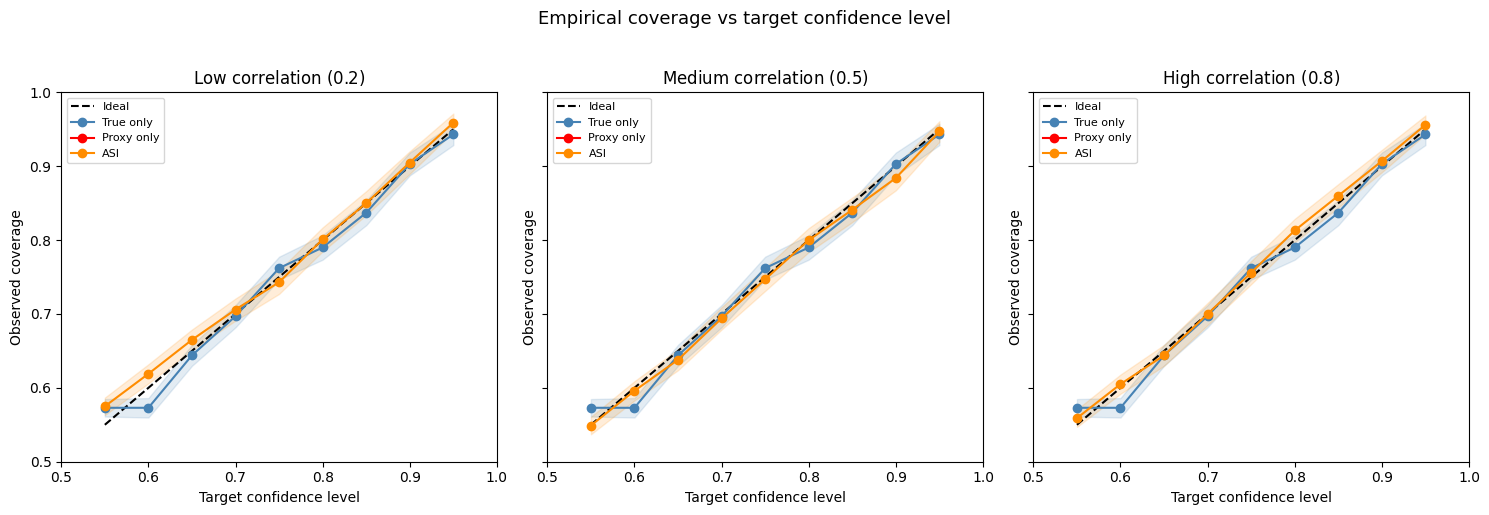

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = {"True only": "steelblue", "ASI": "darkorange", "Proxy only": "red"}

for ax, correlation, label in zip(axes, correlations_lmh, corr_labels):
    ax.plot(confidence_levels, confidence_levels, color="black", lw=1.5, linestyle="--", label="Ideal")
    for method in METHODS:
        mean = [coverages_confidence_intervals[correlation][cl][method][0] for cl in confidence_levels]
        lo = [coverages_confidence_intervals[correlation][cl][method][1] for cl in confidence_levels]
        hi = [coverages_confidence_intervals[correlation][cl][method][2] for cl in confidence_levels]

        ax.plot(confidence_levels, mean, marker="o", color=colors[method], label=method)
        ax.fill_between(confidence_levels, lo, hi, alpha=0.15, color=colors[method])

    ax.set_xlabel("Target confidence level")
    ax.set_ylabel("Observed coverage")
    ax.set_title(f"{label} correlation (${correlation}$)")
    ax.legend(fontsize=8)
    ax.set_xlim(0.5, 1.0)
    ax.set_ylim(0.5, 1.0)

fig.suptitle("Empirical coverage vs target confidence level", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Both **ASI** and **True only** track the diagonal closely across all correlation levels, confirming that ASI achieves valid coverage regardless of proxy quality. The Proxy only method does not show up because it uses biased data so that its coverage is invalid (close to zero).

---

### Coverage vs correlation for fixed confidence level = 0.9

We now fix the confidence level at 90% and vary the proxy-true correlation from 0.1 to 0.9.
This shows that ASI's validity does not degrade as the proxy becomes weaker.

In [22]:
coverage_by_corr = {}
coverage_ci_by_corr = {}

for correlation in correlations:
    hits = compute_hits(raw_stats[correlation], CONFIDENCE_LEVEL)
    coverage_by_corr[correlation] = {}
    coverage_ci_by_corr[correlation] = {}
    for method in METHODS:
        mean_cov, lo, hi = coverage_with_errbar(hits[method], CONFIDENCE_LEVEL)
        coverage_by_corr[correlation][method] = mean_cov
        coverage_ci_by_corr[correlation][method] = (lo, hi)

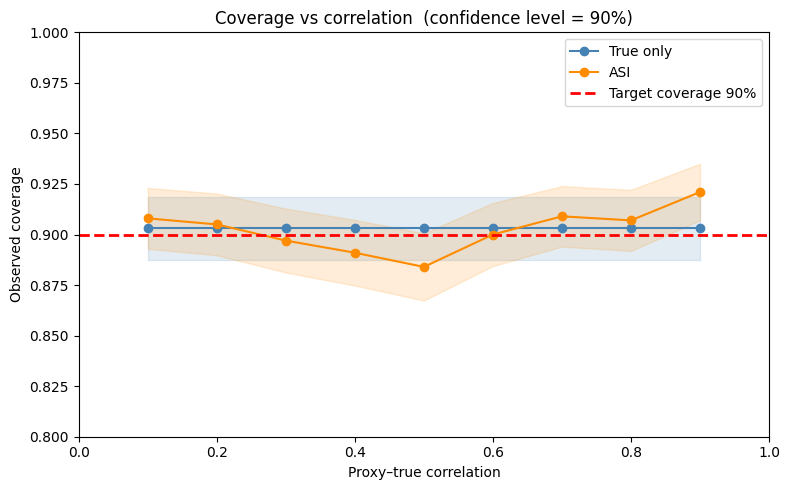

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
method_colors = {"True only": "steelblue", "Proxy only": "red", "ASI": "darkorange"}

for method in ["True only", "ASI"]:
    obs = [coverage_by_corr[correlation][method] for correlation in correlations]
    lo = [coverage_ci_by_corr[correlation][method][0] for correlation in correlations]
    hi = [coverage_ci_by_corr[correlation][method][1] for correlation in correlations]
    ax.plot(correlations, obs, marker="o", color=method_colors[method], label=method)
    ax.fill_between(correlations, lo, hi, alpha=0.15, color=method_colors[method])

ax.axhline(y=CONFIDENCE_LEVEL, color="red", linestyle="--", lw=2, label=f"Target coverage {CONFIDENCE_LEVEL:.0%}")
ax.set_xlabel("Proxy–true correlation")
ax.set_ylabel("Observed coverage")
ax.set_title(f"Coverage vs correlation  (confidence level = {CONFIDENCE_LEVEL:.0%})")
ax.set_xlim(0, 1)
ax.set_ylim(0.8, 1.0)
ax.legend()
plt.tight_layout()
plt.show()

Note that **Proxy only** is not plotted because the proxy is biased (proxy mean ≠ true mean). Therefore it has invalid coverage (close to 0) whereas **ASI** and **True only** remain valid across all correlation levels.

---

## Confidence Interval Width

Coverage validity is necessary but not sufficient, we also want **short** intervals. ASI's promise is that by concentrating the labeling budget on uncertain items, oracle sampling extracts more information per label than uniform sampling.

We report the **mean** and the **10th–90th percentile band** to capture variability.

In [24]:
z_score = norm.ppf((1 + CONFIDENCE_LEVEL) / 2)
width_by_corr = {
    correlation: {method: 2 * z_score * raw_stats[correlation][method]['stds'] for method in METHODS}
    for correlation in correlations
}

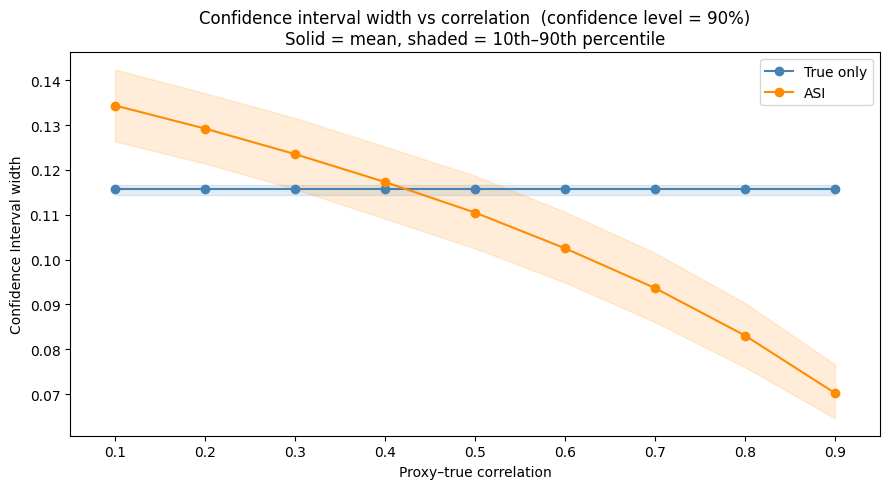

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_methods_w = ["True only", "ASI"]
colors_w = {"True only": "steelblue", "ASI": "darkorange"}

for method in plot_methods_w:
    means_w = [np.mean(width_by_corr[correlation][method]) for correlation in correlations]
    q10 = [np.percentile(width_by_corr[correlation][method], 10) for correlation in correlations]
    q90 = [np.percentile(width_by_corr[correlation][method], 90) for correlation in correlations]
    ax.plot(correlations, means_w, marker="o", label=method, color=colors_w[method])
    ax.fill_between(correlations, q10, q90, alpha=0.15, color=colors_w[method])

ax.set_xlabel("Proxy–true correlation")
ax.set_ylabel("Confidence Interval width")
ax.set_title(
    f"Confidence interval width vs correlation  (confidence level = {CONFIDENCE_LEVEL:.0%})\n"
    "Solid = mean, shaded = 10th–90th percentile"
)
ax.set_xlim(0.05, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

As expected, ASI's interval width decreases with increasing correlation. Leveraging oracle sampling is only beneficial when the proxy is informative enough to have varying reliability across records.

---

## Effective Sample Size

A natural summary of ASI's efficiency gain is the **Effective Sample Size (ESS)**: *it is the number of samples needed by the True only estimation method to achieve the same confidence interval width as ASI with the current labeling budget*

Since confidence interval width $\propto 1/\sqrt{n}$, we can estimate ESS empirically as:

$$\text{ESS} = N_{\text{labeled}} \times \left(\frac{\bar{w}_{\text{True only}}}{\bar{w}_{\text{ASI}}}\right)^2,$$

where $\bar{w}_{\text{True only}}$ and $\bar{w}_{\text{ASI}}$ are the confidence interval widths for True only and ASI respectively.

When the correlation is zero, ESS $\approx N_{\text{labeled}}$ (no gain). As the correlation approaches $1,~$ ESS grows. ASI can be equivalent to having a much larger labeled dataset.

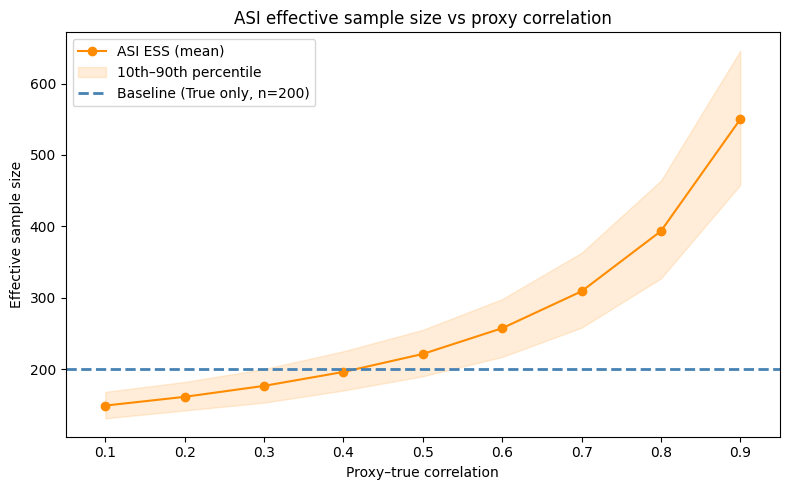

In [26]:
ess_mean = [np.mean(raw_stats[correlation]["ASI"]["effective_sample_size"]) for correlation in correlations]
ess_q10 = [np.percentile(raw_stats[correlation]["ASI"]["effective_sample_size"], 10) for correlation in correlations]
ess_q90 = [np.percentile(raw_stats[correlation]["ASI"]["effective_sample_size"], 90) for correlation in correlations]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(correlations, ess_mean, marker="o", color="darkorange", label="ASI ESS (mean)")
ax.fill_between(correlations, ess_q10, ess_q90, alpha=0.15, color="darkorange", label="10th–90th percentile")
ax.axhline(y=N_LABELED, color="steelblue", linestyle="--", lw=2, label=f"Baseline (True only, n={N_LABELED})")
ax.set_xlabel("Proxy–true correlation")
ax.set_ylabel("Effective sample size")
ax.set_title("ASI effective sample size vs proxy correlation")
ax.set_xlim(0.05, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook has empirically validated that GLIDE's ASI implementation satisfies two key statistical properties:

| Property | Result |
|----------|--------|
| **Coverage validity** | ASI achieves the nominal coverage across all correlation levels and confidence levels tested |
| **Efficiency** | ASI produces shorter confidence intervals than labeled-only whenever correlation is positive, with the gain growing with correlation |

Crucially, the biased baseline (**Proxy only**) fails the coverage test. It appears precise but is systematically wrong. ASI avoids this by correcting for proxy bias via IPW using the labeled subset.

The ESS analysis shows that with a proxy correlation of $0.9,~$ ASI is equivalent to having significantly more labeled data — a practical gain in scenarios where true annotation is expensive. This highlights the importance of a good LLM judge to evaluate an AI system.